In [27]:
# ==============================================================
# CELL 1 – Imports, Hardware Setup & Drive Mount
# ==============================================================
import sys, os, random
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import AdamW
from tqdm import tqdm
from sklearn.metrics import (classification_report, accuracy_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay)

# Set Global Seed for total reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Device Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device in use: {device}')
print(f'PyTorch version: {torch.__version__}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device in use: cuda
PyTorch version: 2.10.0+cu128


In [28]:
import numpy as np
import torch
import torch.nn.functional as F
from scipy.interpolate import CubicSpline

# 1. Path of the Bacteria-ID dataset
data_dir = '/content/drive/MyDrive/Tesi_Raman/Datasets/Bacteria-ID/'
print(f'Loading Bacteria-ID data from {data_dir}...')

x_finetune = np.load(data_dir + 'X_finetune.npy')
y_finetune = np.load(data_dir + 'y_finetune.npy')

X_test_data = np.load(data_dir + 'X_test.npy')
y_test_data = np.load(data_dir + 'y_test.npy')

# Load x-axis (wavenumbers)
try:
    x_axis = np.load(data_dir + 'wavenumbers.npy').flatten()
    print("Asse X (Raman Shift) caricato correttamente da 'wavenumbers.npy'.")
except FileNotFoundError:
    # Fallback just in case the name is slightly different
    print("Non ho trovato 'wavenumbers.npy'. Assicurati che il file si chiami esattamente così nella cartella Bacteria-ID.")
    x_axis = np.linspace(400, 1800, x_finetune.shape[1]) # Fallback fittizio temporaneo

print(f"Range originale: {x_axis.min():.2f} - {x_axis.max():.2f} cm⁻¹")

# Ensure x_axis is strictly increasing for CubicSpline
sort_idx = np.argsort(x_axis)
x_axis_sorted = x_axis[sort_idx]
x_finetune_sorted = x_finetune[:, sort_idx]
X_test_data_sorted = X_test_data[:, sort_idx]

# Interpolate to 1000 equidistant points between 650 and 1750 cm-1
SPECTRA_SIZE = 1000
target_x = np.linspace(650, 1750, SPECTRA_SIZE)

def interpolate_spectra_cubic(x_old, spectra_old, x_new):
    # CubicSpline requires 1D x_old and evaluates over axis=1 for 2D spectra_old
    cs = CubicSpline(x_old, spectra_old, axis=1)
    return cs(x_new)

print(f"Interpolating spectra to {SPECTRA_SIZE} points (650-1750 cm⁻¹) using Cubic Spline...")
x_finetune_interp = interpolate_spectra_cubic(x_axis_sorted, x_finetune_sorted, target_x)
X_test_interp = interpolate_spectra_cubic(x_axis_sorted, X_test_data_sorted, target_x)

# Convert to float32 for PyTorch
x_finetune_interp = x_finetune_interp.astype(np.float32)
X_test_interp = X_test_interp.astype(np.float32)

# Shuffle
def shuffle_in_place(x, y):
    idx = np.random.permutation(len(x))
    return x[idx], y[idx]

X_data, y_finetune = shuffle_in_place(x_finetune_interp, y_finetune)
X_test, y_test_data = shuffle_in_place(X_test_interp, y_test_data)

Y_data = y_finetune.astype(np.int64)
y_test = y_test_data.astype(np.int64)

# Shift to 0-indexed if needed
min_label = min(Y_data.min(), y_test.min())
if min_label > 0:
    Y_data -= min_label
    y_test -= min_label

print("-" * 40)
print(f"X_data (Finetune): {X_data.shape}, Y_data: {Y_data.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")
print(f"Number of classes: {len(np.unique(Y_data))}")


Loading Bacteria-ID data from /content/drive/MyDrive/Tesi_Raman/Datasets/Bacteria-ID/...
Asse X (Raman Shift) caricato correttamente da 'wavenumbers.npy'.
Range originale: 381.98 - 1792.40 cm⁻¹
Interpolating spectra to 1000 points (650-1750 cm⁻¹) using Cubic Spline...
----------------------------------------
X_data (Finetune): (3000, 1000), Y_data: (3000,)
X_test: (3000, 1000), y_test: (3000,)
Number of classes: 30


In [29]:
# ==============================================================
# CELL 3 – Import SpectraMAENet & Load Foundation Weights
# ==============================================================
import subprocess
import sys
import os
import torch

REPO_PATH  = '/content/SpectraMAENet'
MODEL_PATH = os.path.join(REPO_PATH, 'model')

if not os.path.exists(REPO_PATH):
    print("Cloning SpectraMAENet repository...")
    subprocess.run(['git', 'clone', 'https://github.com/pengjuRen99/SpectraMAENet.git', REPO_PATH], check=True)

init_file = os.path.join(MODEL_PATH, '__init__.py')
if not os.path.exists(init_file):
    open(init_file, 'w').close()

for p in [REPO_PATH, MODEL_PATH]:
    if p in sys.path: sys.path.remove(p)
sys.path.insert(0, REPO_PATH)

from model.Spectra_MAE import MaskedAutoencoderViT

# --- Hyperparameters (MANDATORY: Must match Pre-Training perfectly!) ---
SPECTRA_SIZE   = 1000
PATCH_SIZE     = 50
ENCODER_DIM    = 256
ENCODER_DEPTH  = 8
ENCODER_HEADS  = 8
DIM_MLP        = 512   # 2 * ENCODER_DIM
DECODER_DIM    = 128
DECODER_DEPTH  = 1
DECODER_HEADS  = 8  # CORRECT: 8 heads!

def build_smae_encoder():
    """Builds the MAE Architecture."""
    return MaskedAutoencoderViT(
        spectra_size      = SPECTRA_SIZE,
        patch_size        = PATCH_SIZE,
        encoder_dim       = ENCODER_DIM,
        depth             = ENCODER_DEPTH,
        num_heads         = ENCODER_HEADS,
        dim_mlp           = DIM_MLP,
        decoder_embed_dim = DECODER_DIM,
        decoder_depth     = DECODER_DEPTH,
        decoder_num_heads = DECODER_HEADS,
        norm_pix_loss     = False,
    ).to(device)

# CHANGE THIS to point to the .pth file generated by your Pre-Training Notebook
PATH_PRETRAINED = '/content/drive/MyDrive/Tesi_Raman/Models/PreTrain/SMAE/1000_pt/FingerPrint/Min-Max/exp_3/smae_pretrained_model.pth'

print("Loading pre-trained Foundation Model...")
foundation_model = build_smae_encoder()
foundation_model.load_state_dict(torch.load(PATH_PRETRAINED, map_location=device))
foundation_model.eval()

print(f'✅ Foundation Model loaded successfully from: {PATH_PRETRAINED}')


Loading pre-trained Foundation Model...
✅ Foundation Model loaded successfully from: /content/drive/MyDrive/Tesi_Raman/Models/PreTrain/SMAE/1000_pt/FingerPrint/Min-Max/exp_3/smae_pretrained_model.pth


In [30]:
# ==============================================================
# CELL 4 – Classification Model Architecture (Encoder + Head)
# ==============================================================
import torch.nn as nn

class SMAEClassifier(nn.Module):
    """
    Takes the pre-trained SMAE Encoder and attaches a simple Linear Head.
    Includes methods to freeze/unfreeze the encoder for the LP-FT strategy.
    """
    def __init__(self, smae_model, encoder_dim, n_classes=30):
        super().__init__()
        # Extract only the encoder from the MAE
        self.encoder = smae_model

        # Build the Classification Head (Semplificata! Nessun hidden layer)
        self.head = nn.Sequential(
            nn.LayerNorm(encoder_dim),
            nn.Dropout(0.2),  # Manteniamo un po' di dropout per regolarizzare
            nn.Linear(encoder_dim, n_classes)
        )

        self._init_weights()

    def _init_weights(self):
        """Initializes the linear layers of the head."""
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                # Usiamo Xavier per layer lineari diretti
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        latent, _, _ = self.encoder.forward_encoder(x, mask_ratio=0.0)
        emb = latent[:, 1:, :].mean(dim=1)   # Shape: (Batch_Size, encoder_dim)
        logits = self.head(emb)
        return logits

    def freeze_encoder(self):
        for param in self.encoder.parameters():
            param.requires_grad = False
        for param in self.head.parameters():
            param.requires_grad = True

    def unfreeze_encoder(self):
        for param in self.parameters():
            param.requires_grad = True

    def unfreeze_last_n_blocks(self, n=2):
        """
        Scongela solo gli ultimi N blocchi del Transformer e la testa,
        mantenendo i primi blocchi congelati. Ottimo contro l'overfitting!
        """
        self.freeze_encoder() # Congela tutto l'encoder prima

        num_blocks = len(self.encoder.blocks)
        start_block = max(0, num_blocks - n)

        # Scongela gli ultimi N blocchi
        for i in range(start_block, num_blocks):
            for param in self.encoder.blocks[i].parameters():
                param.requires_grad = True

        # Scongela anche la LayerNorm finale dell'encoder (se presente)
        if hasattr(self.encoder, 'norm'):
            for param in self.encoder.norm.parameters():
                param.requires_grad = True


In [31]:
# ==============================================================
# CELL 5 – Train / Val Split (Stratified)
# ==============================================================
from sklearn.model_selection import train_test_split

SEED = 42

# Split Finetune data into 85% Train, 15% Val
X_train, X_val, y_train, y_val = train_test_split(
    X_data, Y_data, test_size=0.2, random_state=SEED, stratify=Y_data
)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Val set:   {X_val.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples (pre-defined)")


Train set: 2400 samples
Val set:   600 samples
Test set:  3000 samples (pre-defined)


In [40]:
# ==============================================================
# CELL 6 – LP-FT FINE-TUNING (Train / Val)
# ==============================================================
import time
import random
import torch
import copy
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score
import numpy as np

# Hyperparameters
LP_EPOCHS = 50
FT_EPOCHS = 100
LP_LR = 1e-3
FT_LR = 1e-5
BATCH_SIZE = 32
PATIENCE = 30
HEAD_DIM = 256

def eval_model(model, loader):
    model.eval()
    preds, labels, probs, losses = [], [], [], []
    criterion = torch.nn.CrossEntropyLoss()
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb)
            loss = criterion(logits, yb)
            losses.append(loss.item())
            probs.append(F.softmax(logits, dim=1).cpu())
            preds.append(logits.argmax(dim=1).cpu())
            labels.append(yb.cpu())
    return (
        torch.cat(preds).numpy(),
        torch.cat(labels).numpy(),
        torch.cat(probs).numpy(),
        np.mean(losses)
    )

# --- CUSTOM DATASET FOR ADVANCED RAMAN DATA AUGMENTATION ---
class RamanAugmentedDataset(Dataset):
    def __init__(self, X, y, augment=False, max_shift=15, max_mask_size=40):
        self.X = X
        self.y = y
        self.augment = augment
        self.max_shift = max_shift
        self.max_mask_size = max_mask_size

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x_val = self.X[idx].clone()
        if self.augment:
            # 1. Random intensity multiplier (+/- 5%)
            scale = random.uniform(0.95, 1.05)
            x_val = x_val * scale

            # 2. Very light Gaussian noise to simulate instrumental noise
            noise = torch.randn_like(x_val) * 1e-4
            x_val = x_val + noise

            # 3. Random Shift (Traslazione orizzontale)
            shift = random.randint(-self.max_shift, self.max_shift)
            if shift != 0:
                x_val_shifted = torch.empty_like(x_val)
                if shift > 0:
                    x_val_shifted[:, :shift] = x_val[:, 0]
                    x_val_shifted[:, shift:] = x_val[:, :-shift]
                else:
                    x_val_shifted[:, shift:] = x_val[:, -1]
                    x_val_shifted[:, :shift] = x_val[:, -shift:]
                x_val = x_val_shifted

            # 4. Random Masking (Erasing) con 50% di probabilita
            if random.random() < 0.5:
                mask_size = random.randint(10, self.max_mask_size)
                start_idx = random.randint(0, x_val.shape[1] - mask_size)
                x_val[:, start_idx : start_idx + mask_size] = 0.0

        return x_val, self.y[idx]

# Base data
Xtr = torch.from_numpy(X_train).unsqueeze(1)
ytr = torch.from_numpy(y_train)
Xva = torch.from_numpy(X_val).unsqueeze(1)
yva = torch.from_numpy(y_val)

# DataLoaders with Augmentation ONLY on the Train Set
train_dataset = RamanAugmentedDataset(Xtr, ytr, augment=True)
val_dataset = RamanAugmentedDataset(Xva, yva, augment=False)

loader_tr = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
loader_va = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

num_classes = len(np.unique(Y_data))
model = SMAEClassifier(copy.deepcopy(foundation_model), ENCODER_DIM, n_classes=num_classes).to(device)

# Class weights
class_counts = torch.bincount(ytr)
weights = 1.0 / class_counts.float()
weights[class_counts == 0] = 0.0
weights = weights / weights.sum() * num_classes
weights = weights.to(device)

criterion = torch.nn.CrossEntropyLoss(weight=weights)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "train_f1": [], "val_f1": [], "lr": []}

# --- STAGE 1: LP ---
print("STAGE 1: Linear Probing")
model.freeze_encoder()
optimizer_lp = AdamW(model.head.parameters(), lr=LP_LR)
scheduler_lp = ReduceLROnPlateau(optimizer_lp, mode='min', factor=0.5, patience=10)

for epoch in range(LP_EPOCHS):
    model.train()
    total_loss = 0
    all_preds_tr = []
    all_labels_tr = []
    for Xb, yb in loader_tr:
        optimizer_lp.zero_grad()
        logits = model(Xb.to(device))
        loss = criterion(logits, yb.to(device))
        loss.backward()
        optimizer_lp.step()
        total_loss += loss.item()
        all_preds_tr.append(logits.argmax(dim=1).detach().cpu())
        all_labels_tr.append(yb.detach().cpu())

    train_preds = torch.cat(all_preds_tr).numpy()
    train_labels = torch.cat(all_labels_tr).numpy()
    train_acc = accuracy_score(train_labels, train_preds)
    train_f1 = f1_score(train_labels, train_preds, average="macro")

    preds_val, labels_val, probs_val, val_loss = eval_model(model, loader_va)
    val_acc = accuracy_score(labels_val, preds_val)
    val_f1 = f1_score(labels_val, preds_val, average="macro")

    scheduler_lp.step(val_loss)

    train_loss_epoch = total_loss/len(loader_tr)
    history["train_loss"].append(train_loss_epoch)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)
    history["lr"].append(optimizer_lp.param_groups[0]['lr'])

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"[LP] Epoch {epoch+1:02d}/{LP_EPOCHS} | Train Loss: {train_loss_epoch:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

# --- STAGE 2: FT ---
print("\nSTAGE 2: Fine-Tuning")
model.unfreeze_encoder()
optimizer_ft = AdamW(model.parameters(), lr=FT_LR)
scheduler_ft = ReduceLROnPlateau(optimizer_ft, mode='min', factor=0.5, patience=8)

best_acc = 0.0
best_loss = float('inf')
no_improve = 0
best_state = None

for epoch in range(FT_EPOCHS):
    model.train()
    total_loss = 0
    all_preds_tr = []
    all_labels_tr = []
    for Xb, yb in loader_tr:
        optimizer_ft.zero_grad()
        logits = model(Xb.to(device))
        loss = criterion(logits, yb.to(device))
        loss.backward()
        optimizer_ft.step()
        total_loss += loss.item()
        all_preds_tr.append(logits.argmax(dim=1).detach().cpu())
        all_labels_tr.append(yb.detach().cpu())

    train_preds = torch.cat(all_preds_tr).numpy()
    train_labels = torch.cat(all_labels_tr).numpy()
    train_acc = accuracy_score(train_labels, train_preds)
    train_f1 = f1_score(train_labels, train_preds, average="macro")

    preds_val, labels_val, probs_val, val_loss = eval_model(model, loader_va)
    val_acc = accuracy_score(labels_val, preds_val)
    val_f1 = f1_score(labels_val, preds_val, average="macro")

    scheduler_ft.step(val_loss)

    train_loss_epoch = total_loss/len(loader_tr)
    history["train_loss"].append(train_loss_epoch)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)
    history["lr"].append(optimizer_ft.param_groups[0]['lr'])

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"[FT] Epoch {epoch+1:02d}/{FT_EPOCHS} | Train Loss: {train_loss_epoch:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    # 1. Save the best model based on Accuracy
    if val_acc > best_acc:
        best_acc = val_acc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    elif val_acc == best_acc and val_loss < best_loss:
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    # 2. Early stopping based on Validation Loss
    if val_loss < best_loss:
        best_loss = val_loss
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1} (No improvement in Val Loss)")
            break

model.load_state_dict(best_state)
print("\nTraining Completed. Best Val Accuracy:", best_acc, "| Best Val Loss:", best_loss)


STAGE 1: Linear Probing
[LP] Epoch 01/50 | Train Loss: 3.6865 | Val Loss: 3.2801 | Train Acc: 0.0362 | Val Acc: 0.0983
[LP] Epoch 10/50 | Train Loss: 2.6740 | Val Loss: 2.4253 | Train Acc: 0.2137 | Val Acc: 0.3317
[LP] Epoch 20/50 | Train Loss: 2.3809 | Val Loss: 2.1658 | Train Acc: 0.2838 | Val Acc: 0.3467
[LP] Epoch 30/50 | Train Loss: 2.2493 | Val Loss: 2.0204 | Train Acc: 0.3196 | Val Acc: 0.3750
[LP] Epoch 40/50 | Train Loss: 2.1657 | Val Loss: 1.9447 | Train Acc: 0.3488 | Val Acc: 0.4083
[LP] Epoch 50/50 | Train Loss: 2.1046 | Val Loss: 1.8792 | Train Acc: 0.3688 | Val Acc: 0.4650

STAGE 2: Fine-Tuning
[FT] Epoch 01/100 | Train Loss: 2.0247 | Val Loss: 1.6965 | Train Acc: 0.3821 | Val Acc: 0.5217
[FT] Epoch 10/100 | Train Loss: 1.1788 | Val Loss: 0.8835 | Train Acc: 0.6379 | Val Acc: 0.7350
[FT] Epoch 20/100 | Train Loss: 0.8143 | Val Loss: 0.5654 | Train Acc: 0.7283 | Val Acc: 0.8000
[FT] Epoch 30/100 | Train Loss: 0.6059 | Val Loss: 0.4851 | Train Acc: 0.7967 | Val Acc: 0.8417


In [41]:
# ============================================================
# CELL 7 — Test Set Evaluation
# ============================================================
from sklearn.metrics import roc_auc_score

Xte = torch.from_numpy(X_test).unsqueeze(1)
yte = torch.from_numpy(y_test)
loader_te = DataLoader(TensorDataset(Xte, yte), batch_size=BATCH_SIZE, shuffle=False)

preds_test, labels_test, probs_test, test_loss = eval_model(model, loader_te)

print("Test Accuracy:", accuracy_score(labels_test, preds_test))
print("Test Macro-F1:", f1_score(labels_test, preds_test, average="macro"))

try:
    # Multi-class ROC AUC
    auc = roc_auc_score(labels_test, probs_test, multi_class='ovr')
    print("Test ROC-AUC (OVR):", auc)
except ValueError:
    print("Test ROC-AUC: N/A (Some classes might be missing in y_true)")

Test Accuracy: 0.7616666666666667
Test Macro-F1: 0.7503677054258431
Test ROC-AUC (OVR): 0.9860100000000002


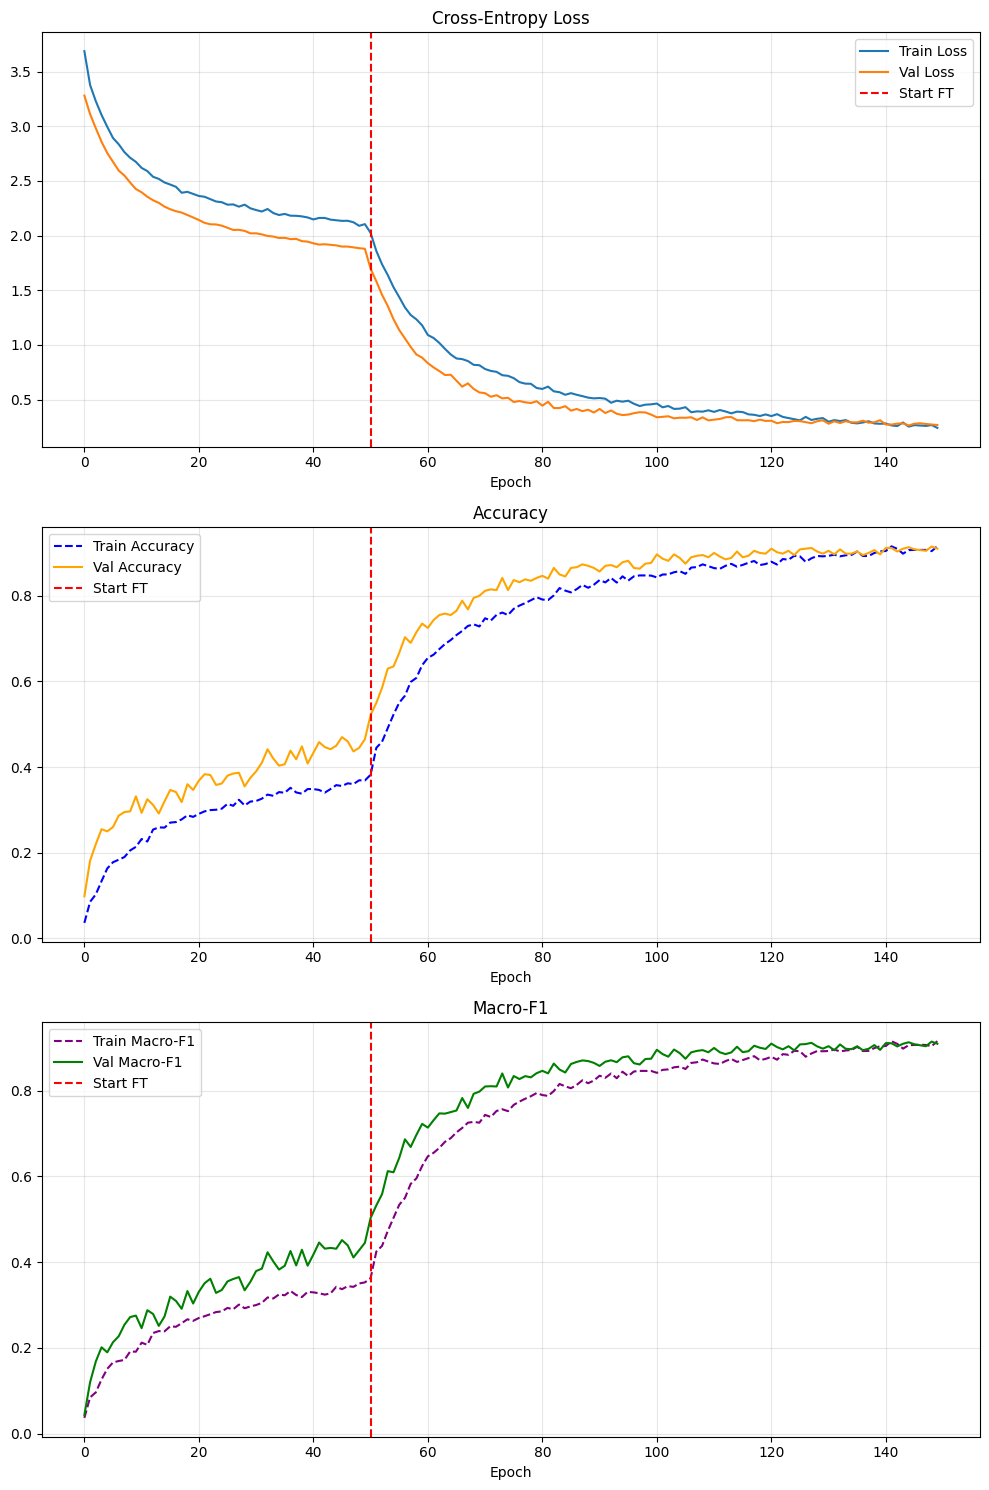

In [42]:
# ============================================================
# CELL 8 — Training Curves
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# --- Loss ---
axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].axvline(LP_EPOCHS, color='r', linestyle='--', label='Start FT')
axes[0].set_title("Cross-Entropy Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Accuracy ---
axes[1].plot(history["train_acc"], label="Train Accuracy", color='blue', linestyle='--')
axes[1].plot(history["val_acc"], label="Val Accuracy", color='orange')
axes[1].axvline(LP_EPOCHS, color='r', linestyle='--', label='Start FT')
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

# --- F1 Score ---
axes[2].plot(history["train_f1"], label="Train Macro-F1", color='purple', linestyle='--')
axes[2].plot(history["val_f1"], label="Val Macro-F1", color='green')
axes[2].axvline(LP_EPOCHS, color='r', linestyle='--', label='Start FT')
axes[2].set_title("Macro-F1")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


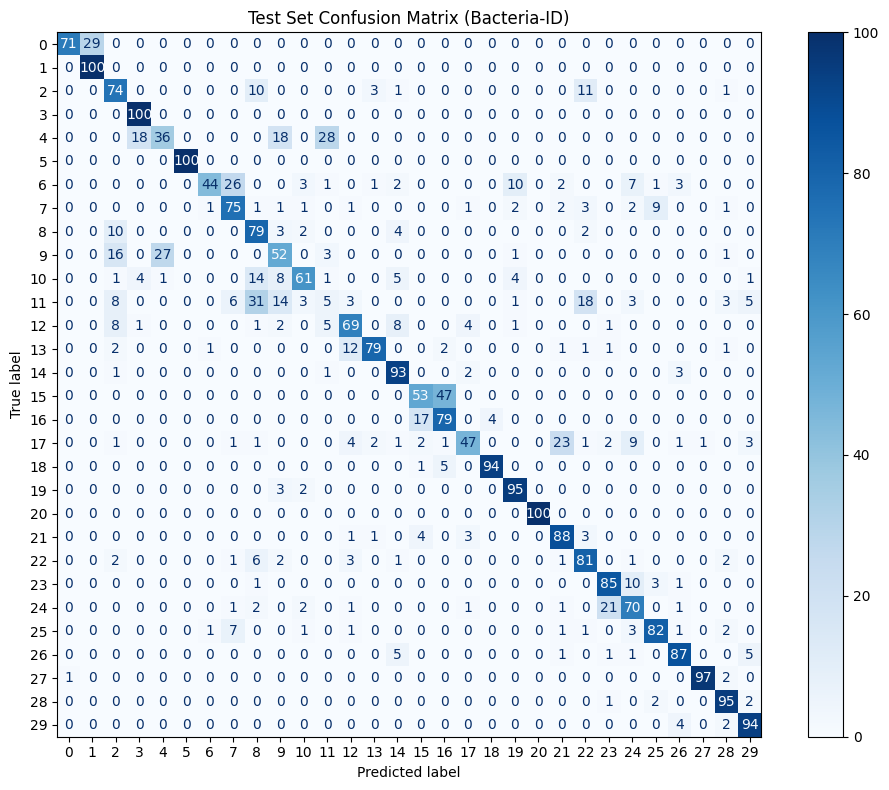


 GLOBAL CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

           0       0.99      0.71      0.83       100
           1       0.78      1.00      0.87       100
           2       0.60      0.74      0.66       100
           3       0.81      1.00      0.90       100
           4       0.56      0.36      0.44       100
           5       1.00      1.00      1.00       100
           6       0.94      0.44      0.60       100
           7       0.64      0.75      0.69       100
           8       0.54      0.79      0.64       100
           9       0.50      0.52      0.51       100
          10       0.81      0.61      0.70       100
          11       0.11      0.05      0.07       100
          12       0.73      0.69      0.71       100
          13       0.92      0.79      0.85       100
          14       0.78      0.93      0.85       100
          15       0.69      0.53      0.60       100
          16       0.59      0.79      

In [43]:
# ============================================================
# CELL 9 — Clinical Evaluation & Scientific Plotting
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

fig, ax1 = plt.subplots(1, 1, figsize=(10, 8))

# 1. Confusion Matrix
# We remove display_labels since we have 30 classes now
cm = confusion_matrix(labels_test, preds_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', ax=ax1, colorbar=True)
ax1.set_title("Test Set Confusion Matrix (Bacteria-ID)")

# NOTE: ROC and PR curves natively from_predictions in sklearn
# are mainly for binary classification. For 30 classes, it's
# usually better to compute them OVR (One-Vs-Rest) if needed.

plt.tight_layout()
plt.show()

print('\n' + '='*50)
print(' GLOBAL CLASSIFICATION REPORT (Test Set)')
print('='*50)
# Remove target_names to let it use class indices 0-29
print(classification_report(labels_test, preds_test))


In [36]:
# ============================================================
# CELL 12 — Caricamento asse X (Raman Shift)
# ============================================================
import numpy as np

# Load the x-axis (Raman shift) from the .npy file
data_dir = '/content/drive/MyDrive/Tesi_Raman/Datasets/Bacteria-ID/'
x_axis = np.load(data_dir + 'wavenumbers.npy').flatten()

print("Asse X (Raman Shift) caricato correttamente da 'wavenumbers.npy'.")
print(f"Range: {x_axis.min():.2f} - {x_axis.max():.2f} cmⁱ¹")


Asse X (Raman Shift) caricato correttamente da 'wavenumbers.npy'.
Range: 381.98 - 1792.40 cmⁱ¹


### 📊 Valutazione K-Fold delle metriche sul Test Set
Alleniamo il modello 5 volte su fold diversi del set di training/validation unito (85% dei dati). Ad ogni fold, calcoliamo le metriche direttamente sul **Test Set isolato (15%)**. Alla fine, calcoliamo la **media e la deviazione standard** delle metriche sul Test Set per valutare la stabilità del modello al variare dei dati di addestramento.

In [44]:
# ============================================================
# CELL 13 — K-Fold: Media delle metriche sul Test Set (30 Classes)
# ============================================================
import numpy as np
import torch
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
import copy

set_seed(42)

print("Preparazione dati per K-Fold...")
X_cv = np.concatenate((X_train, X_val), axis=0)
y_cv = np.concatenate((y_train, y_val), axis=0)

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

test_accuracies = []
test_f1s = []
test_aucs = []

K_LP_EPOCHS = 50
K_FT_EPOCHS = 100
K_BATCH_SIZE = 32
PATIENCE = 30
NUM_CLASSES = len(np.unique(Y_data))

Xte_t = torch.from_numpy(X_test).unsqueeze(1).to(device)
yte_t = y_test

for fold, (train_idx, val_idx) in enumerate(skf.split(X_cv, y_cv)):
    print(f"\n--- Inizio FOLD {fold+1}/{N_SPLITS} ---")

    X_tr_f, y_tr_f = X_cv[train_idx], y_cv[train_idx]
    X_va_f, y_va_f = X_cv[val_idx], y_cv[val_idx]

    Xtr_t = torch.from_numpy(X_tr_f).unsqueeze(1)
    ytr_t = torch.from_numpy(y_tr_f)
    Xva_t = torch.from_numpy(X_va_f).unsqueeze(1)
    yva_t = torch.from_numpy(y_va_f)

    train_ds = RamanAugmentedDataset(Xtr_t, ytr_t, augment=True)
    val_ds   = RamanAugmentedDataset(Xva_t, yva_t, augment=False)

    loader_tr = DataLoader(train_ds, batch_size=K_BATCH_SIZE, shuffle=True)
    loader_va = DataLoader(val_ds, batch_size=K_BATCH_SIZE, shuffle=False)

    model_f = SMAEClassifier(copy.deepcopy(foundation_model), ENCODER_DIM, n_classes=NUM_CLASSES).to(device)

    # Pesi per classi sbilanciate come nell'holdout
    class_counts = torch.bincount(ytr_t)
    weights = 1.0 / class_counts.float()
    weights[class_counts == 0] = 0.0
    weights = weights / weights.sum() * NUM_CLASSES
    weights = weights.to(device)
    criterion_f = torch.nn.CrossEntropyLoss(weight=weights)

    # --- STAGE 1: LP ---
    print("  -> STAGE 1: Linear Probing")
    model_f.freeze_encoder()
    opt_lp = AdamW(model_f.head.parameters(), lr=1e-3)
    sch_lp = ReduceLROnPlateau(opt_lp, mode='min', factor=0.5, patience=10)
    for ep in range(K_LP_EPOCHS):
        model_f.train()
        tot_loss = 0
        for Xb, yb in loader_tr:
            opt_lp.zero_grad()
            loss = criterion_f(model_f(Xb.to(device)), yb.to(device))
            loss.backward()
            opt_lp.step()
            tot_loss += loss.item()

        _, _, _, v_loss = eval_model(model_f, loader_va)
        sch_lp.step(v_loss)

        if (ep + 1) % 10 == 0 or ep == 0:
            print(f"     [LP] Epoch {ep+1:02d}/{K_LP_EPOCHS} | Train Loss: {tot_loss/len(loader_tr):.4f} | Val Loss: {v_loss:.4f}")

    # --- STAGE 2: FT ---
    print("  -> STAGE 2: Full Fine-Tuning")
    model_f.unfreeze_encoder() # Come nell'holdout

    opt_ft = AdamW(filter(lambda p: p.requires_grad, model_f.parameters()), lr=1e-5)
    sch_ft = ReduceLROnPlateau(opt_ft, mode='min', factor=0.5, patience=8)

    best_loss = float('inf')
    best_acc = 0.0
    best_state = None
    no_imp = 0

    for ep in range(K_FT_EPOCHS):
        model_f.train()
        tot_loss = 0
        for Xb, yb in loader_tr:
            opt_ft.zero_grad()
            loss = criterion_f(model_f(Xb.to(device)), yb.to(device))
            loss.backward()
            opt_ft.step()
            tot_loss += loss.item()

        preds_va, labels_va, _, v_loss = eval_model(model_f, loader_va)
        v_acc = accuracy_score(labels_va, preds_va)
        sch_ft.step(v_loss)

        if (ep + 1) % 10 == 0 or ep == 0:
            print(f"     [FT] Epoch {ep+1:02d}/{K_FT_EPOCHS} | Train Loss: {tot_loss/len(loader_tr):.4f} | Val Loss: {v_loss:.4f} | Val Acc: {v_acc:.4f}")

        if v_acc > best_acc:
            best_acc = v_acc
            best_state = {k: v.clone() for k, v in model_f.state_dict().items()}
        elif v_acc == best_acc and v_loss < best_loss:
            best_state = {k: v.clone() for k, v in model_f.state_dict().items()}

        if v_loss < best_loss:
            best_loss = v_loss
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= PATIENCE:
                print(f"     [!] Early stopping at epoch {ep+1}")
                break

    if best_state is not None:
        model_f.load_state_dict(best_state)

    # --- VALUTAZIONE SUL TEST SET ---
    model_f.eval()
    with torch.no_grad():
        logits = model_f(Xte_t)
        probs = torch.nn.functional.softmax(logits, dim=1).cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()

    acc = accuracy_score(yte_t, preds)
    f1 = f1_score(yte_t, preds, average="macro")
    try:
        auc = roc_auc_score(yte_t, probs, multi_class='ovr')
    except:
        auc = 0.0

    print(f"  -> Risultati Test Set (Fold {fold+1}) -> Accuracy: {acc:.4f} | Macro-F1: {f1:.4f} | AUC: {auc:.4f}")

    test_accuracies.append(acc)
    test_f1s.append(f1)
    test_aucs.append(auc)

print("\n" + "="*60)
print(" METRICHE MEDIE SUL TEST SET (Cross-Validation a 5 Fold) ")
print("="*60)
print(f"Test Accuracy : {np.mean(test_accuracies):.4f} \u00B1 {np.std(test_accuracies):.4f}")
print(f"Test Macro-F1 : {np.mean(test_f1s):.4f} \u00B1 {np.std(test_f1s):.4f}")
print(f"Test ROC-AUC  : {np.mean(test_aucs):.4f} \u00B1 {np.std(test_aucs):.4f}")


Preparazione dati per K-Fold...

--- Inizio FOLD 1/5 ---
  -> STAGE 1: Linear Probing
     [LP] Epoch 01/50 | Train Loss: 3.6283 | Val Loss: 3.2367
     [LP] Epoch 10/50 | Train Loss: 2.6384 | Val Loss: 2.4520
     [LP] Epoch 20/50 | Train Loss: 2.3710 | Val Loss: 2.2003
     [LP] Epoch 30/50 | Train Loss: 2.2575 | Val Loss: 2.0970
     [LP] Epoch 40/50 | Train Loss: 2.1638 | Val Loss: 1.9981
     [LP] Epoch 50/50 | Train Loss: 2.1206 | Val Loss: 1.9356
  -> STAGE 2: Full Fine-Tuning
     [FT] Epoch 01/100 | Train Loss: 2.0091 | Val Loss: 1.7664 | Val Acc: 0.4817
     [FT] Epoch 10/100 | Train Loss: 1.1632 | Val Loss: 0.9409 | Val Acc: 0.6917
     [FT] Epoch 20/100 | Train Loss: 0.7886 | Val Loss: 0.6222 | Val Acc: 0.8033
     [FT] Epoch 30/100 | Train Loss: 0.6117 | Val Loss: 0.4955 | Val Acc: 0.8400
     [FT] Epoch 40/100 | Train Loss: 0.5164 | Val Loss: 0.4641 | Val Acc: 0.8533
     [FT] Epoch 50/100 | Train Loss: 0.4366 | Val Loss: 0.4156 | Val Acc: 0.8650
     [FT] Epoch 60/100 | 

In [45]:
# ============================================================
# ViT FROM SCRATCH - SIMPLE HOLD-OUT (Train/Val/Test 70-15-15)
# ============================================================
import copy
import torch
import numpy as np
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

set_seed(42)

# Re-use the existing X_train, X_val, X_test splits from Cell 5
Xtr_t = torch.from_numpy(X_train).unsqueeze(1)
ytr_t = torch.from_numpy(y_train)
Xva_t = torch.from_numpy(X_val).unsqueeze(1)
yva_t = torch.from_numpy(y_val)
Xte_t = torch.from_numpy(X_test).unsqueeze(1).to(device)

# Datasets / DataLoaders
train_ds = RamanAugmentedDataset(Xtr_t, ytr_t, augment=True)
val_ds = RamanAugmentedDataset(Xva_t, yva_t, augment=False)

loader_tr = DataLoader(train_ds, batch_size=32, shuffle=True)
loader_va = DataLoader(val_ds, batch_size=32, shuffle=False)

# Model Init for Multi-Class
NUM_CLASSES = len(np.unique(Y_data))
vit_encoder_scratch_ho = build_smae_encoder()
model_scratch_ho = SMAEClassifier(vit_encoder_scratch_ho, ENCODER_DIM, n_classes=NUM_CLASSES).to(device)
model_scratch_ho.unfreeze_encoder()

# Loss weights for multi-class
class_counts = torch.bincount(ytr_t)
pesi = 1.0 / class_counts.float()
pesi[class_counts == 0] = 0.0
w_t = pesi / pesi.sum() * NUM_CLASSES
w_t = w_t.to(device)
criterion_scratch_ho = torch.nn.CrossEntropyLoss(weight=w_t)

print("--- Training ViT from Scratch (Hold-Out) ---")
opt = AdamW(model_scratch_ho.parameters(), lr=1e-4)
sch = ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=8)

best_state = None
best_acc = 0.0
best_loss = float('inf')
patience_counter = 0

EPOCHS = 150
for ep in range(EPOCHS):
    model_scratch_ho.train()
    for Xb, yb in loader_tr:
        opt.zero_grad()
        loss = criterion_scratch_ho(model_scratch_ho(Xb.to(device)), yb.to(device))
        loss.backward()
        opt.step()

    preds_va, labels_va, _, v_loss = eval_model(model_scratch_ho, loader_va)
    v_acc = accuracy_score(labels_va, preds_va)
    sch.step(v_loss)

    if v_acc > best_acc:
        best_acc = v_acc
        best_state = {k: v.clone() for k, v in model_scratch_ho.state_dict().items()}
    elif v_acc == best_acc and v_loss < best_loss:
        best_state = {k: v.clone() for k, v in model_scratch_ho.state_dict().items()}

    if v_loss < best_loss:
        best_loss = v_loss
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= 20:
            print(f"Early stopping @ epoch {ep+1}")
            break

model_scratch_ho.load_state_dict(best_state)
model_scratch_ho.eval()

with torch.no_grad():
    logits = model_scratch_ho(Xte_t)
    probs = torch.softmax(logits, dim=1).cpu().numpy()
    preds = logits.argmax(dim=1).cpu().numpy()

acc = accuracy_score(y_test, preds)
f1 = f1_score(y_test, preds, average='macro')
try:
    auc = roc_auc_score(y_test, probs, multi_class='ovr')
except:
    auc = 0.0

print(f"\n[Test Set Results - Hold-Out Scratch]")
print(f"Accuracy : {acc:.4f}")
print(f"Macro-F1 : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")


--- Training ViT from Scratch (Hold-Out) ---
Early stopping @ epoch 73

[Test Set Results - Hold-Out Scratch]
Accuracy : 0.7180
Macro-F1 : 0.6998
ROC-AUC  : 0.9805


In [46]:
# ============================================================
# ViT FROM SCRATCH - STANDARD K-FOLD (Valuta su Test Set fisso)
# ============================================================
import numpy as np
import torch
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader

set_seed(42)

# Use Train+Val for CV, Test is held out
X_cv = np.concatenate((X_train, X_val), axis=0)
y_cv = np.concatenate((y_train, y_val), axis=0)

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

test_accuracies_scratch_kf = []
test_f1s_scratch_kf = []
test_aucs_scratch_kf = []

NUM_CLASSES = len(np.unique(Y_data))
Xte_t = torch.from_numpy(X_test).unsqueeze(1).to(device)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_cv, y_cv)):
    print(f"\n--- FOLD {fold+1}/{N_SPLITS} (ViT From Scratch) ---")

    X_tr_f, y_tr_f = X_cv[train_idx], y_cv[train_idx]
    X_va_f, y_va_f = X_cv[val_idx], y_cv[val_idx]

    Xtr_t = torch.from_numpy(X_tr_f).unsqueeze(1)
    ytr_t = torch.from_numpy(y_tr_f)
    Xva_t = torch.from_numpy(X_va_f).unsqueeze(1)
    yva_t = torch.from_numpy(y_va_f)

    train_ds = RamanAugmentedDataset(Xtr_t, ytr_t, augment=True)
    val_ds   = RamanAugmentedDataset(Xva_t, yva_t, augment=False)

    loader_tr = DataLoader(train_ds, batch_size=32, shuffle=True)
    loader_va = DataLoader(val_ds, batch_size=32, shuffle=False)

    # Init from scratch
    vit_encoder_scratch_kf = build_smae_encoder()
    model_scratch_kf = SMAEClassifier(vit_encoder_scratch_kf, ENCODER_DIM, n_classes=NUM_CLASSES).to(device)
    model_scratch_kf.unfreeze_encoder()

    class_counts = torch.bincount(ytr_t)
    weights = 1.0 / class_counts.float()
    weights[class_counts == 0] = 0.0
    w_t = weights / weights.sum() * NUM_CLASSES
    w_t = w_t.to(device)
    criterion_scratch_kf = torch.nn.CrossEntropyLoss(weight=w_t)

    opt = AdamW(model_scratch_kf.parameters(), lr=1e-4)
    sch = ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=8)

    best_state = None
    best_f1 = 0.0
    best_loss = float('inf')
    no_imp = 0

    for ep in range(150):
        model_scratch_kf.train()
        for Xb, yb in loader_tr:
            opt.zero_grad()
            loss = criterion_scratch_kf(model_scratch_kf(Xb.to(device)), yb.to(device))
            loss.backward()
            opt.step()

        preds_va, labels_va, _, v_loss = eval_model(model_scratch_kf, loader_va)
        v_f1 = f1_score(labels_va, preds_va, average="macro")
        sch.step(v_loss)

        if v_f1 > best_f1:
            best_f1 = v_f1
            best_state = {k: v.clone() for k, v in model_scratch_kf.state_dict().items()}
        elif v_f1 == best_f1 and v_loss < best_loss:
            best_state = {k: v.clone() for k, v in model_scratch_kf.state_dict().items()}

        if v_loss < best_loss:
            best_loss = v_loss
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= 20:
                print(f"     Early stopping at epoch {ep+1}")
                break

    model_scratch_kf.load_state_dict(best_state)
    model_scratch_kf.eval()
    with torch.no_grad():
        logits = model_scratch_kf(Xte_t)
        probs = torch.nn.functional.softmax(logits, dim=1).cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")
    try:
        auc = roc_auc_score(y_test, probs, multi_class='ovr')
    except:
        auc = 0.0

    print(f"  -> Test Set (Fold {fold+1}) -> Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

    test_accuracies_scratch_kf.append(acc)
    test_f1s_scratch_kf.append(f1)
    test_aucs_scratch_kf.append(auc)

print("\n" + "="*60)
print(" METRICHE MEDIE TEST SET - K-FOLD (ViT Da Zero) ")
print("="*60)
print(f"Test Accuracy : {np.mean(test_accuracies_scratch_kf):.4f} ± {np.std(test_accuracies_scratch_kf):.4f}")
print(f"Test Macro-F1 : {np.mean(test_f1s_scratch_kf):.4f} ± {np.std(test_f1s_scratch_kf):.4f}")
print(f"Test ROC-AUC  : {np.mean(test_aucs_scratch_kf):.4f} ± {np.std(test_aucs_scratch_kf):.4f}")


--- FOLD 1/5 (ViT From Scratch) ---
     Early stopping at epoch 113
  -> Test Set (Fold 1) -> Acc: 0.7580 | F1: 0.7461 | AUC: 0.9851

--- FOLD 2/5 (ViT From Scratch) ---
     Early stopping at epoch 120
  -> Test Set (Fold 2) -> Acc: 0.7290 | F1: 0.7138 | AUC: 0.9752

--- FOLD 3/5 (ViT From Scratch) ---
  -> Test Set (Fold 3) -> Acc: 0.7330 | F1: 0.7205 | AUC: 0.9805

--- FOLD 4/5 (ViT From Scratch) ---
     Early stopping at epoch 112
  -> Test Set (Fold 4) -> Acc: 0.7260 | F1: 0.7140 | AUC: 0.9821

--- FOLD 5/5 (ViT From Scratch) ---
     Early stopping at epoch 97
  -> Test Set (Fold 5) -> Acc: 0.7357 | F1: 0.7306 | AUC: 0.9846

 METRICHE MEDIE TEST SET - K-FOLD (ViT Da Zero) 
Test Accuracy : 0.7363 ± 0.0113
Test Macro-F1 : 0.7250 ± 0.0122
Test ROC-AUC  : 0.9815 ± 0.0036
